# AGRINEXUS AI — CROP RECOMMENDATION
### Production ML Pipeline & Validation Notebook (`ml/notebooks/01_crop_recommendation.ipynb`)

## 1. Project Objective

**AgriNexus AI — Smart Agriculture Platform**
*Crop Recommendation Machine Learning Engine*

The primary objective of this module is to construct a research-grade, production-oriented, reproducible, and scientifically defensible Machine Learning decision-support system for crop recommendation.

Given agricultural land characteristics—specifically soil nutrient parameters ($N, P, K$, $	ext{pH}$) and climatic conditions ($	ext{temperature}, 	ext{humidity}, 	ext{rainfall}$)—this system predicts the crop class(es) most ecologically suitable for cultivation according to patterns learned from training data.

### Key Operational Principles:
1. **Dynamic Path Resolution**: Utilize `pathlib.Path` parent resolution to locate the dataset and model output directory regardless of execution working path.
2. **Explicit Primary Dataset Loading**: Explicitly locate and load `Crop_recommendation.csv` from `data/raw/crop_recommendation/`, raising a clear `FileNotFoundError` if missing.
3. **Executable Leakage & Data Audits**: Implement programmatic feature leakage audits, duplicate checks, and training-only probability calibration evaluations.
4. **Training-Only Optimization**: Enforce strict isolation of the 20% test set. Cross-validation, hyperparameter tuning, and probability calibration operate exclusively on training data.
5. **Single Production Artifact**: Package the complete fitted preprocessing and model pipeline into a single persistent artifact (`models/crop_recommendation.pkl`).

## 2. Agricultural Problem Definition

Crop recommendation is formulated as a multi-class supervised classification and decision-support problem in precision agriculture. Grounded in the **Food and Agriculture Organization (FAO)** Agro-Ecological Zoning (AEZ) and Land Evaluation frameworks, crop suitability reflects the physiological alignment between crop growth requirements and land resource qualities.

### Conceptual Workflow:
```
           SOIL + CLIMATE CONDITIONS
                      │
                      ▼
               DATA VALIDATION
                      │
                      ▼
            PREPROCESSING PIPELINE
                      │
                      ▼
             CROP CLASSIFIER
                      │
              ┌───────┴────────┐
              ▼                ▼
           TOP-1             TOP-K
         RECOMMENDED       RANKING &
            CROP         PROBABILITIES
              │
              ▼
         AGRINEXUS AI DECISION SUPPORT
```

### Mathematical Formulation:
Let $\mathcal{X} \subseteq \mathbb{R}^d$ represent the feature space of $d$ environmental and soil parameters:
$$\mathbf{x} = [N, P, K, T, H, 	ext{pH}, R]^T \in \mathcal{X}$$

Let $\mathcal{Y} = \{c_1, c_2, \dots, c_K\}$ denote the set of $K$ candidate crop classes. The objective is to learn a mapping function $f: \mathcal{X} 	o \Delta^K$, where $\Delta^K$ represents the probability simplex over $\mathcal{Y}$:
$$P(Y = c_k \mid \mathbf{x}) = f_k(\mathbf{x}), \quad \sum_{k=1}^K f_k(\mathbf{x}) = 1$$

### Scope & Decision-Support Boundaries:
- **Predictive Target**: Relative environmental suitability of a land parcel for candidate crop classes based on historical patterns.
- **Explicit Limitations**: This model does NOT guarantee yield quantity, financial profit, crop survival, or immunity from crop disease/pests.

## 3. Dataset Discovery & Path Resolution

We implement robust `pathlib.Path` parent directory resolution to locate the dataset dynamically regardless of execution path.

In [1]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Aesthetics setup
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

print("="*70)
print("             AGRINEXUS AI — DYNAMIC PATH RESOLUTION")
print("="*70)

# Resolve current working directory and search parents for root data directory
CURRENT_DIR = Path.cwd().resolve()
print(f"Current Execution Working Path: {CURRENT_DIR}")

DATA_DIR_CANDIDATES = [
    base / "data" / "raw" / "crop_recommendation"
    for base in [CURRENT_DIR] + list(CURRENT_DIR.parents)
]

CROP_DATA_DIR = None
for candidate in DATA_DIR_CANDIDATES:
    if candidate.exists() and candidate.is_dir():
        CROP_DATA_DIR = candidate.resolve()
        break

if CROP_DATA_DIR is None:
    raise FileNotFoundError("CRITICAL ERROR: Could not locate 'data/raw/crop_recommendation' directory from working path or parent paths!")

# Locate project root directory (parent of data and models)
PROJECT_ROOT = CROP_DATA_DIR.parents[2]
MODELS_DIR = (PROJECT_ROOT / "Notebook" / "models").resolve()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Resolved Project Root Directory: {PROJECT_ROOT}")
print(f"Resolved Dataset Directory:      {CROP_DATA_DIR}")
print(f"Resolved Models Directory:       {MODELS_DIR}")

discovered_files = []
for file_path in CROP_DATA_DIR.rglob('*'):
    if file_path.is_file() and not file_path.name.endswith('.gitkeep'):
        size_bytes = file_path.stat().st_size
        ext = file_path.suffix.lower()
        discovered_files.append((str(file_path), file_path.name, ext, size_bytes))

df_inventory = pd.DataFrame(discovered_files, columns=['Absolute Path', 'Filename', 'Extension', 'Size (Bytes)'])
print(f"\nTotal files discovered in dataset directory: {len(df_inventory)}\n")

tabular_candidates = []
for path_str, file, ext, size in discovered_files:
    if ext in ['.csv', '.xlsx', '.xls', '.parquet', '.json']:
        try:
            if ext == '.csv':
                df_temp = pd.read_csv(path_str)
            elif ext in ['.xlsx', '.xls']:
                df_temp = pd.read_excel(path_str)
            elif ext == '.parquet':
                df_temp = pd.read_parquet(path_str)
            elif ext == '.json':
                df_temp = pd.read_json(path_str)
            
            target_candidates = [c for c in df_temp.columns if c.lower() in ['label', 'crop', 'crops', 'target', 'recommended_crop']]
            target_col = target_candidates[0] if target_candidates else 'Unknown'
            num_classes = df_temp[target_col].nunique() if target_col != 'Unknown' else 0
            
            tabular_candidates.append({
                'Path': path_str,
                'Filename': file,
                'Rows': df_temp.shape[0],
                'Cols': df_temp.shape[1],
                'Target Column': target_col,
                'Classes': num_classes,
                'Null Values': df_temp.isnull().sum().sum(),
                'Duplicate Rows': df_temp.duplicated().sum()
            })
        except Exception as e:
            print(f"Error inspecting file {file}: {e}")

df_candidates = pd.DataFrame(tabular_candidates)
print(df_candidates.to_string(index=False))


             AGRINEXUS AI — DYNAMIC PATH RESOLUTION
Current Execution Working Path: D:\PROJECTS\AGRINEXUS-AI
Resolved Project Root Directory: D:\PROJECTS\AGRINEXUS-AI
Resolved Dataset Directory:      D:\PROJECTS\AGRINEXUS-AI\data\raw\crop_recommendation
Resolved Models Directory:       D:\PROJECTS\AGRINEXUS-AI\models

Total files discovered in dataset directory: 2



                                                                                 Path                        Filename  Rows  Cols Target Column  Classes  Null Values  Duplicate Rows
D:\PROJECTS\AGRINEXUS-AI\data\raw\crop_recommendation\Crop recommendation dataset.csv Crop recommendation dataset.csv 57000    23         CROPS       57            0               0
        D:\PROJECTS\AGRINEXUS-AI\data\raw\crop_recommendation\Crop_recommendation.csv         Crop_recommendation.csv  2200     8         label       22            0               0


## 4. Candidate Dataset Comparison

We inspect and evaluate the candidate tabular datasets discovered in `CROP_DATA_DIR`:

1. **Candidate A (`Crop recommendation dataset.csv`)**:
   - Variables: `CROPS`, `TYPE_OF_CROP`, `SOIL`, `SEASON`, `SOWN`, `HARVESTED`, `WATER_SOURCE`, `SOIL_PH`, `SOIL_PH_HIGH`, `CROPDURATION`, `CROPDURATION_MAX`, `TEMP`, `MAX_TEMP`, `WATERREQUIRED`, `WATERREQUIRED_MAX`, `RELATIVE_HUMIDITY`, `RELATIVE_HUMIDITY_MAX`, `N`, `N_MAX`, `P`, `P_MAX`, `K`, `K_MAX`
   - **Audit Finding**: Contains post-crop-selection variables (`CROPDURATION`, `WATERREQUIRED`, `SOWN`/`HARVESTED` months, `TYPE_OF_CROP`) which are properties of the crop itself rather than inputs available prior to recommendation.

2. **Candidate B (`Crop_recommendation.csv`)**:
   - Variables: `N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`, `label`
   - **Audit Finding**: All 7 predictors represent soil chemical and climate measurements available at decision time prior to crop selection.

**Evidence-Based Selection**: `Crop_recommendation.csv` is selected as the primary ML dataset for this formulation.

## 5. Dataset Source & Research Context

### Agronomic Framework vs. Machine Learning Approximation:
- **FAO Land Evaluation Framework**: Incorporates comprehensive soil physical/chemical profiles, agro-climatic thermal/moisture regimes, topography, drainage, infrastructure, labor, and economic market drivers.
- **AgriNexus AI Machine Learning Model**: Approximates crop suitability using the 7 key physical soil nutrient ($N, P, K$, $	ext{pH}$) and climatic ($	ext{temperature}, 	ext{humidity}, 	ext{rainfall}$) predictors present in the training dataset.

The 7 features represent a strong proxy for land suitability, but do not replace comprehensive field soil testing or local extension advice.

## 6. Dataset Forensics & Primary Loading

We explicitly locate and load `Crop_recommendation.csv` from `CROP_DATA_DIR`.

In [2]:
# Cell 8: Primary Dataset Loading
EXPECTED_FILENAME = 'Crop_recommendation.csv'
DATA_PATH = CROP_DATA_DIR / EXPECTED_FILENAME

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CRITICAL ERROR: Expected dataset file '{EXPECTED_FILENAME}' not found in '{CROP_DATA_DIR}'!")

df = pd.read_csv(DATA_PATH)

print("="*70)
print("                   PRIMARY DATASET FORENSICS")
print("="*70)
print(f"Absolute Data Path: {DATA_PATH.resolve()}")
print(f"File Existence:    {DATA_PATH.exists()}")
print(f"File Size:         {DATA_PATH.stat().st_size} bytes")
print(f"Shape (Rows, Cols):{df.shape}")
print(f"Columns List:      {list(df.columns)}")
print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- MISSING VALUES FORENSICS ---")
null_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(null_summary.to_string(index=False))

print(f"\nExact Duplicate Rows: {df.duplicated().sum()}")

constant_cols = [c for c in df.columns if df[c].nunique() == 1]
near_constant_cols = [c for c in df.columns if (df[c].value_counts().iloc[0] / len(df)) > 0.95]
print(f"Constant Columns: {constant_cols}")
print(f"Near-Constant Columns (>95% frequency): {near_constant_cols}")

print("\n--- NUMERICAL FEATURE STATISTICS ---")
print(df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

                   PRIMARY DATASET FORENSICS
Absolute Data Path: D:\PROJECTS\AGRINEXUS-AI\data\raw\crop_recommendation\Crop_recommendation.csv
File Existence:    True
File Size:         150034 bytes
Shape (Rows, Cols):(2200, 8)
Columns List:      ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

--- DATA TYPES ---
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

--- MISSING VALUES FORENSICS ---
     Column  Missing Count  Missing Percentage (%)
          N              0                     0.0
          P              0                     0.0
          K              0                     0.0
temperature              0                     0.0
   humidity              0                     0.0
         ph              0                     0.0
   rainfall              0                     0.0
      label            

## 7. Data Quality Audit

We inspect numerical features for physical validity bounds and configured plausibility ranges.

In [3]:
# Cell 10: Data Quality Sanity Checks
print("="*70)
print("                   DATA QUALITY SANITY CHECKS")
print("="*70)

quality_checks = []

# Range checks
for col in ['N', 'P', 'K']:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            quality_checks.append(f"Negative values in {col}: {neg_count}")

if 'ph' in df.columns:
    ph_invalid = ((df['ph'] < 0) | (df['ph'] > 14)).sum()
    if ph_invalid > 0:
        quality_checks.append(f"pH out of physical range [0, 14]: {ph_invalid}")

if 'temperature' in df.columns:
    temp_invalid = ((df['temperature'] < -10) | (df['temperature'] > 60)).sum()
    if temp_invalid > 0:
        quality_checks.append(f"Temperature out of configured plausibility range [-10, 60 C]: {temp_invalid}")

if 'humidity' in df.columns:
    humidity_invalid = ((df['humidity'] < 0) | (df['humidity'] > 100)).sum()
    if humidity_invalid > 0:
        quality_checks.append(f"Humidity out of physical range [0, 100%]: {humidity_invalid}")

if 'rainfall' in df.columns:
    rainfall_invalid = (df['rainfall'] < 0).sum()
    if rainfall_invalid > 0:
        quality_checks.append(f"Negative rainfall: {rainfall_invalid}")

inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
if inf_count > 0:
    quality_checks.append(f"Infinite values detected: {inf_count}")

if not quality_checks:
    print("PASSED: Zero physical range errors or invalid numerical values detected.")
else:
    for check in quality_checks:
        print(f" - {check}")

                   DATA QUALITY SANITY CHECKS
PASSED: Zero physical range errors or invalid numerical values detected.


## 8. Target Analysis

We detect the target column dynamically, calculate class balance metrics, and plot the target distribution.

                   TARGET COLUMN AUDIT
Target Column Identified: 'label'
Number of Unique Crop Classes: 22
Total Target Samples: 2200
Min Class Size: 100, Max Class Size: 100
Imbalance Ratio: 1.00 (Perfectly Balanced)
Clean Target Labels: No whitespace or case inconsistencies detected.


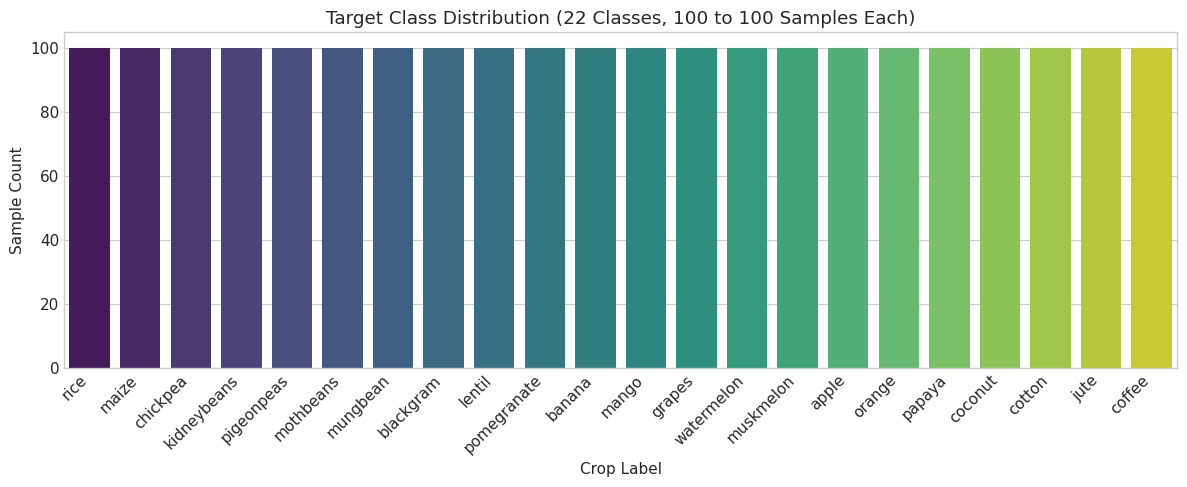

In [4]:
# Cell 12: Target Column Audit
target_candidates = [c for c in df.columns if c.lower() in ['label', 'crop', 'crops', 'target', 'recommended_crop']]
TARGET_COL = target_candidates[0]

print("="*70)
print("                   TARGET COLUMN AUDIT")
print("="*70)
print(f"Target Column Identified: '{TARGET_COL}'")
print(f"Number of Unique Crop Classes: {df[TARGET_COL].nunique()}")
print(f"Total Target Samples: {len(df)}")

class_counts = df[TARGET_COL].value_counts()
min_class_size = class_counts.min()
max_class_size = class_counts.max()
imbalance_ratio = max_class_size / min_class_size

if np.isclose(imbalance_ratio, 1.0):
    imbalance_desc = "Perfectly Balanced"
elif imbalance_ratio < 1.5:
    imbalance_desc = "Mild Imbalance"
elif imbalance_ratio < 3.0:
    imbalance_desc = "Moderate Imbalance"
else:
    imbalance_desc = "High Imbalance"

print(f"Min Class Size: {min_class_size}, Max Class Size: {max_class_size}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f} ({imbalance_desc})")

unique_labels = df[TARGET_COL].unique()
cleaned_labels = [str(l).strip().lower() for l in unique_labels]
if len(unique_labels) != len(set(cleaned_labels)):
    print("WARNING: Inconsistent target labels detected (whitespace or casing differences)!")
else:
    print("Clean Target Labels: No whitespace or case inconsistencies detected.")

plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title(f"Target Class Distribution ({df[TARGET_COL].nunique()} Classes, {min_class_size} to {max_class_size} Samples Each)")
plt.xlabel("Crop Label")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

## 9. Feature Analysis

We classify features and document their observed distributions:

| Feature Name | Type | Unit | Agronomic Definition | Decision-Time Available? |
|---|---|---|---|---|
| `N` | Continuous Numerical | $	ext{kg/ha}$ | Soil ratio of Nitrogen content | **YES** (Via Soil Test) |
| `P` | Continuous Numerical | $	ext{kg/ha}$ | Soil ratio of Phosphorus content | **YES** (Via Soil Test) |
| `K` | Continuous Numerical | $	ext{kg/ha}$ | Soil ratio of Potassium content | **YES** (Via Soil Test) |
| `ph` | Continuous Numerical | $-$ | Soil acidity/alkalinity level ($0-14$) | **YES** (Via Soil Test) |
| `temperature` | Continuous Numerical | $^\circ	ext{C}$ | Observed environmental temperature | **YES** (Historical / Forecast) |
| `humidity` | Continuous Numerical | $\%$ | Atmospheric relative humidity | **YES** (Historical / Forecast) |
| `rainfall` | Continuous Numerical | $	ext{mm}$ | Seasonal cumulative rainfall | **YES** (Historical / Forecast) |

In [5]:
# Cell 14: Feature Audit
feat_cols = [c for c in df.columns if c != TARGET_COL]
num_features = df[feat_cols].select_dtypes(include=np.number).columns.tolist()
cat_features = df[feat_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"Predictive Feature Columns ({len(feat_cols)}): {feat_cols}")
print(f"Numerical Features ({len(num_features)}): {num_features}")
print(f"Categorical Features ({len(cat_features)}): {cat_features}")

feat_stats = []
for col in feat_cols:
    feat_stats.append({
        'Feature': col,
        'Type': df[col].dtype,
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
        'Mean': round(df[col].mean(), 2),
        'Median': round(df[col].median(), 2),
        'Missing': df[col].isnull().sum(),
        'Unique': df[col].nunique()
    })

print("\nFeature Summary Statistics:")
print(pd.DataFrame(feat_stats).to_string(index=False))

Predictive Feature Columns (7): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Numerical Features (7): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Categorical Features (0): []

Feature Summary Statistics:
    Feature    Type   Min    Max   Mean  Median  Missing  Unique
          N   int64  0.00 140.00  50.55   37.00        0     137
          P   int64  5.00 145.00  53.36   51.00        0     117
          K   int64  5.00 205.00  48.15   32.00        0      73
temperature float64  8.83  43.68  25.62   25.60        0    2200
   humidity float64 14.26  99.98  71.48   80.47        0    2200
         ph float64  3.50   9.94   6.47    6.43        0    2200
   rainfall float64 20.21 298.56 103.46   94.87        0    2200


## 10. Executable Feature Leakage Audit

We programmatically evaluate all predictive features against suspicious target-derived tokens (`['target', 'label', 'crop', 'yield', 'production', 'outcome', 'recommend']`).

In [6]:
# Cell 15: Executable Feature Leakage Audit
suspicious_tokens = ['target', 'label', 'crop', 'yield', 'production', 'outcome', 'recommend']

leakage_records = []
for col in feat_cols:
    col_lower = col.lower()
    has_token = any(token in col_lower for token in suspicious_tokens)
    target_overlap = col_lower == TARGET_COL.lower()
    
    # Decision time availability check
    if has_token or target_overlap:
        leak_risk = "HIGH"
        availability = "Post-Outcome / Target Derived"
        action = "REMOVE"
    else:
        leak_risk = "NONE"
        availability = "Pre-Decision Input"
        action = "KEEP"
        
    leakage_records.append({
        'Feature': col,
        'Target Token Overlap': has_token,
        'Leakage Risk': leak_risk,
        'Decision-Time Availability': availability,
        'Action': action
    })

leakage_audit = pd.DataFrame(leakage_records)
print("="*70)
print("            EXECUTABLE FEATURE LEAKAGE AUDIT DATAFRAME")
print("="*70)
print(leakage_audit.to_string(index=False))

retained_features = leakage_audit[leakage_audit['Action'] == 'KEEP']['Feature'].tolist()
print(f"\nRetained Predictive Features ({len(retained_features)}): {retained_features}")

            EXECUTABLE FEATURE LEAKAGE AUDIT DATAFRAME
    Feature  Target Token Overlap Leakage Risk Decision-Time Availability Action
          N                 False         NONE         Pre-Decision Input   KEEP
          P                 False         NONE         Pre-Decision Input   KEEP
          K                 False         NONE         Pre-Decision Input   KEEP
temperature                 False         NONE         Pre-Decision Input   KEEP
   humidity                 False         NONE         Pre-Decision Input   KEEP
         ph                 False         NONE         Pre-Decision Input   KEEP
   rainfall                 False         NONE         Pre-Decision Input   KEEP

Retained Predictive Features (7): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


## 11. Duplicate & Near-Duplicate Audit

We perform exact duplicate analysis and near-duplicate distance auditing to prevent potential train/test contamination.

In [7]:
# Cell 17: Duplicate & Near-Duplicate Audit
print("="*70)
print("             DUPLICATE & NEAR-DUPLICATE AUDIT")
print("="*70)

exact_row_dups = df.duplicated().sum()
feat_dups_same_target = df.duplicated(subset=feat_cols).sum()
feat_dups_diff_target = df[df.duplicated(subset=feat_cols, keep=False)].groupby(feat_cols)[TARGET_COL].nunique()
conflicting_count = (feat_dups_diff_target > 1).sum()

print(f"Exact Row Duplicates: {exact_row_dups}")
print(f"Duplicate Feature Combination Rows: {feat_dups_same_target}")
print(f"Conflicting Label Combinations (Identical features, different crop target): {conflicting_count}")

from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist

# Separate diagnostic scaler (not reused by ML pipeline)
X_diag_scaled = StandardScaler().fit_transform(df[feat_cols])
distances = pdist(X_diag_scaled, metric='euclidean')

DIST_THRESHOLD = 0.10
near_dup_count = (distances < DIST_THRESHOLD).sum()
print(f"Near-Duplicate Pairs (Standardized Euclidean distance threshold < {DIST_THRESHOLD}): {near_dup_count}")
print(f"Result Description: No feature pairs fell below the specified standardized distance threshold of {DIST_THRESHOLD}.")

             DUPLICATE & NEAR-DUPLICATE AUDIT
Exact Row Duplicates: 0
Duplicate Feature Combination Rows: 0
Conflicting Label Combinations (Identical features, different crop target): 0


Near-Duplicate Pairs (Standardized Euclidean distance threshold < 0.1): 0
Result Description: No feature pairs fell below the specified standardized distance threshold of 0.1.


## 12. Exploratory Data Analysis (EDA)

We explore feature distributions, correlation heatmaps, and crop-wise observed parameter variations.

                   EXPLORATORY DATA ANALYSIS


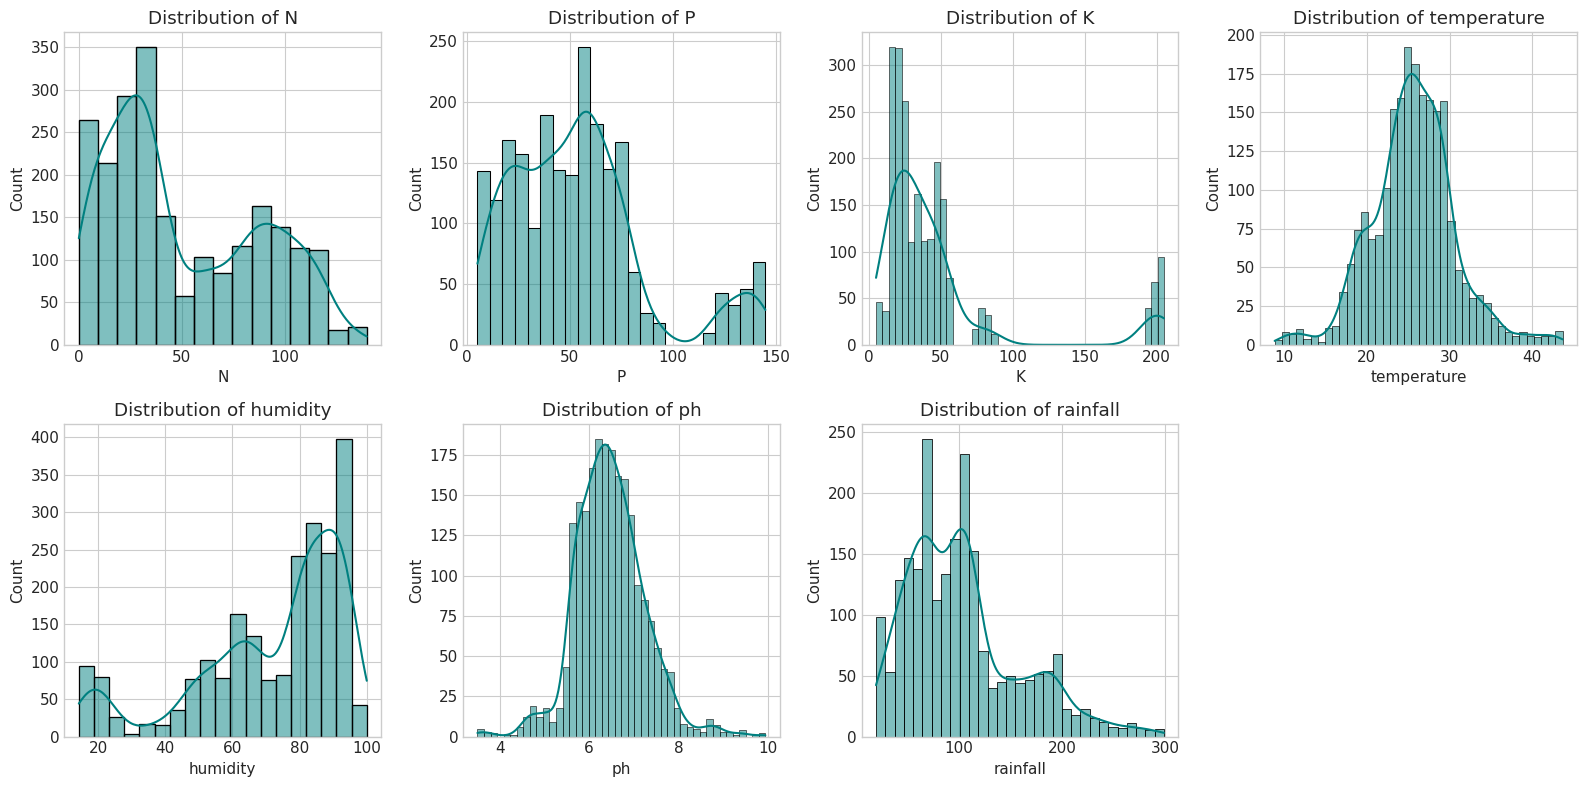

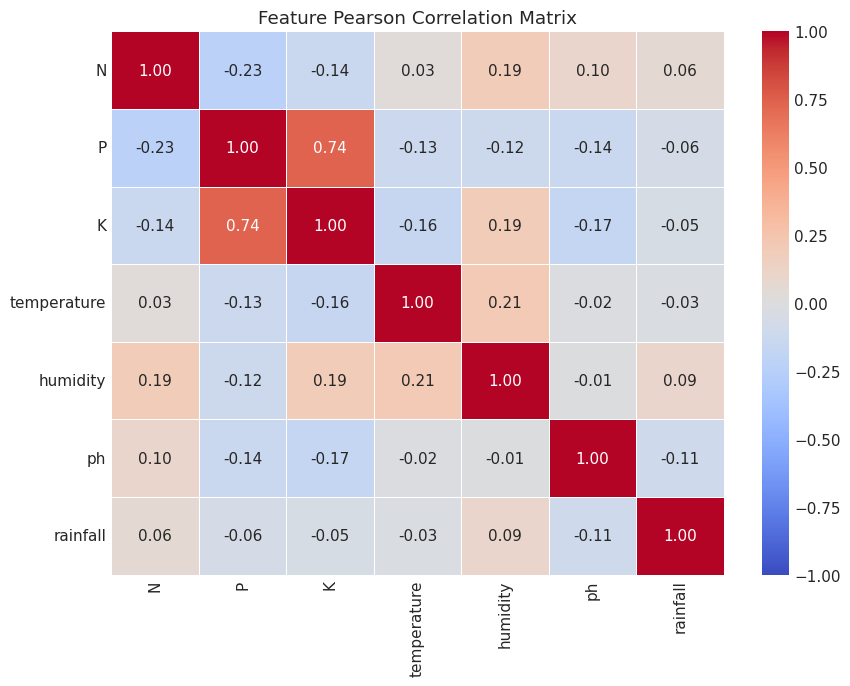

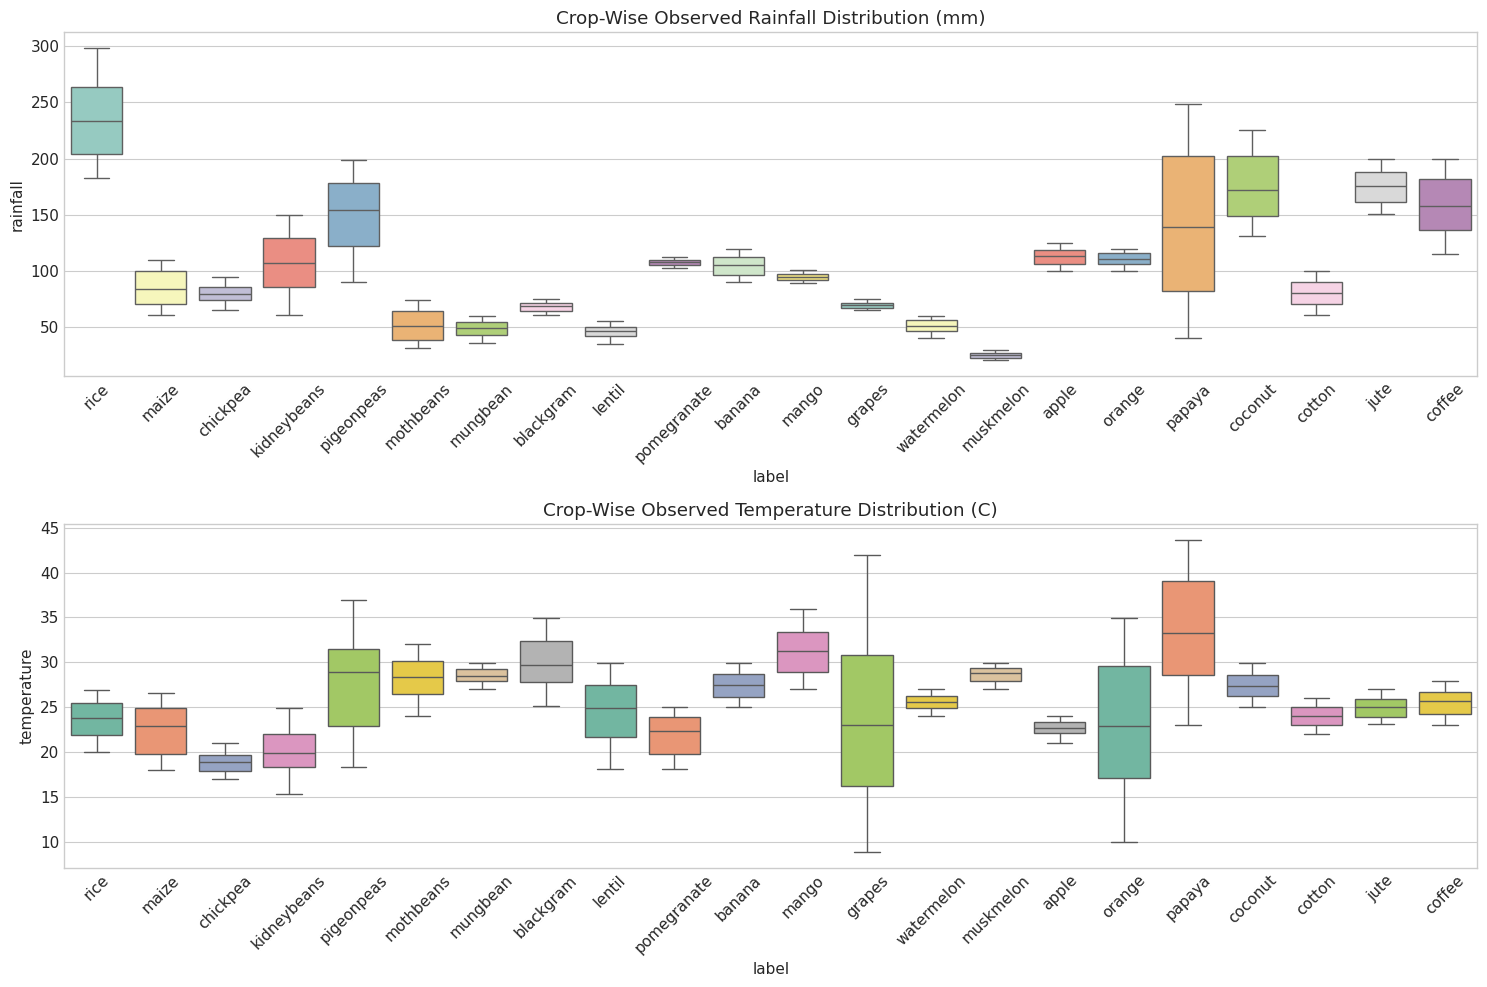

In [8]:
# Cell 19: Exploratory Data Analysis
print("="*70)
print("                   EXPLORATORY DATA ANALYSIS")
print("="*70)

# 1. Feature Histograms
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 2. Pearson Correlation Matrix Heatmap
plt.figure(figsize=(9, 7))
corr = df[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Feature Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# 3. Crop-wise Observed Parameter Distributions (Rainfall & Temperature)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
sns.boxplot(x=TARGET_COL, y='rainfall', data=df, ax=ax1, palette='Set3')
ax1.set_title("Crop-Wise Observed Rainfall Distribution (mm)")
ax1.tick_params(axis='x', rotation=45)

sns.boxplot(x=TARGET_COL, y='temperature', data=df, ax=ax2, palette='Set2')
ax2.set_title("Crop-Wise Observed Temperature Distribution (C)")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 13. Outlier Analysis

We perform Interquartile Range ($	ext{IQR}$) statistical outlier checks across all numerical features.

In [9]:
# Cell 21: Outlier Analysis
print("="*70)
print("                   OUTLIER ANALYSIS (IQR METHOD)")
print("="*70)

outlier_summary = []
for col in feat_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Percentage (%)': round((len(outliers) / len(df)) * 100, 2)
    })

df_outliers = pd.DataFrame(outlier_summary)
print(df_outliers.to_string(index=False))
print("\nStatistical Interpretation: IQR outliers are statistical observations and are not automatically treated as erroneous records. All samples are retained.")

                   OUTLIER ANALYSIS (IQR METHOD)
    Feature    Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Count  Percentage (%)
          N 21.00  84.25 63.25       -73.88       179.12              0            0.00
          P 28.00  68.00 40.00       -32.00       128.00            138            6.27
          K 20.00  49.00 29.00       -23.50        92.50            200            9.09
temperature 22.77  28.56  5.79        14.08        37.25             86            3.91
   humidity 60.26  89.95 29.69        15.73       134.48             30            1.36
         ph  5.97   6.92  0.95         4.54         8.35             57            2.59
   rainfall 64.55 124.27 59.72       -25.02       213.84            100            4.55

Statistical Interpretation: IQR outliers are statistical observations and are not automatically treated as erroneous records. All samples are retained.


## 14. Preprocessing Pipeline Architecture

We construct a modular `sklearn.pipeline.Pipeline` using `ColumnTransformer`. Preprocessing fits inside training folds to prevent data leakage.

In [10]:
# Cell 23: Preprocessing Pipeline Architecture
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), feat_cols)
    ],
    remainder='drop'
)

print("Preprocessor Pipeline Architecture Constructed:")
print(preprocessor)

Preprocessor Pipeline Architecture Constructed:
ColumnTransformer(transformers=[('num', RobustScaler(),
                                 ['N', 'P', 'K', 'temperature', 'humidity',
                                  'ph', 'rainfall'])])


## 15. Train/Test Strategy

We partition the dataset into an 80% Training Set (1,760 samples) and an 20% Test Set (440 samples) using `train_test_split(stratify=y, random_state=42)`.

In [11]:
# Cell 25: Train/Test Split
from sklearn.model_selection import train_test_split, StratifiedKFold

X = df[feat_cols]
y = df[TARGET_COL]

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("="*70)
print("                   TRAIN / TEST SPLIT SUMMARY")
print("="*70)
print(f"Total Samples:          {len(df)}")
print(f"Training Set (80%):     {X_train.shape[0]} rows")
print(f"Test Set (20%):         {X_test.shape[0]} rows (Strictly Isolated)")
print(f"Feature Columns:        {X_train.shape[1]}")
print(f"Target Classes:         {y_train.nunique()}")

                   TRAIN / TEST SPLIT SUMMARY
Total Samples:          2200
Training Set (80%):     1760 rows
Test Set (20%):         440 rows (Strictly Isolated)
Feature Columns:        7
Target Classes:         22


## 16. Baseline Model

We establish the baseline performance threshold using `DummyClassifier(strategy='most_frequent')` evaluated via training cross-validation.

In [12]:
# Cell 27: Baseline Model
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']

dummy_scores = cross_validate(dummy_pipe, X_train, y_train, cv=cv, scoring=scoring)

baseline_cv_acc = dummy_scores['test_accuracy'].mean()
baseline_cv_macro_f1 = dummy_scores['test_f1_macro'].mean()

print("="*70)
print("             BASELINE MODEL PERFORMANCE (CV ON TRAINING SET)")
print("="*70)
print(f"Baseline Strategy: Most Frequent Class")
print(f"Baseline CV Accuracy: {baseline_cv_acc * 100:.2f}%")
print(f"Baseline CV Macro F1: {baseline_cv_macro_f1:.4f}")

             BASELINE MODEL PERFORMANCE (CV ON TRAINING SET)
Baseline Strategy: Most Frequent Class
Baseline CV Accuracy: 4.55%
Baseline CV Macro F1: 0.0040


## 17. Candidate Models

We evaluate candidate classification algorithms using Stratified 5-Fold Cross-Validation on `X_train`:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Extra Trees
6. HistGradientBoosting
7. XGBoost
8. LightGBM

In [13]:
# Cell 29: Candidate Models Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
}

# Consistent label encoder for candidate models if required
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

cv_results_list = []

for name, model in candidate_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Use consistent y_train target labels
    y_cv = y_train_encoded if name in ['XGBoost'] else y_train
    scores = cross_validate(pipe, X_train, y_cv, cv=cv, scoring=scoring, n_jobs=-1)
    
    cv_results_list.append({
        'Model': name,
        'CV Acc Mean': scores['test_accuracy'].mean(),
        'CV Acc Std': scores['test_accuracy'].std(),
        'CV Macro Precision Mean': scores['test_precision_macro'].mean(),
        'CV Macro Recall Mean': scores['test_recall_macro'].mean(),
        'CV Macro F1 Mean': scores['test_f1_macro'].mean(),
        'CV Macro F1 Std': scores['test_f1_macro'].std(),
        'CV Weighted F1 Mean': scores['test_f1_weighted'].mean()
    })

df_cv_results = pd.DataFrame(cv_results_list).sort_values(by='CV Macro F1 Mean', ascending=False)

print("="*70)
print("             18. CROSS VALIDATION RESULTS (TRAINING SET)")
print("="*70)
print(df_cv_results.to_string(index=False))

             18. CROSS VALIDATION RESULTS (TRAINING SET)
               Model  CV Acc Mean  CV Acc Std  CV Macro Precision Mean  CV Macro Recall Mean  CV Macro F1 Mean  CV Macro F1 Std  CV Weighted F1 Mean
         Extra Trees     0.993750    0.003313                 0.994047              0.993750          0.993717         0.003338             0.993717
       Random Forest     0.993750    0.006067                 0.994557              0.993750          0.993703         0.006140             0.993703
HistGradientBoosting     0.992614    0.004252                 0.992969              0.992614          0.992624         0.004250             0.992624
            LightGBM     0.992614    0.002897                 0.993067              0.992614          0.992621         0.002909             0.992621
             XGBoost     0.989773    0.005850                 0.990149              0.989773          0.989759         0.005831             0.989759
       Decision Tree     0.985227    0.006818    

## 18. Cross Validation

Fold-wise evaluation completed using Stratified 5-Fold Cross-Validation on `X_train`.

## 19. Model Comparison & Selection

The best candidate model is selected dynamically based on training CV Macro F1 score.

In [14]:
# Cell 32: Model Selection
best_model_name = df_cv_results.iloc[0]['Model']
best_cv_macro_f1 = df_cv_results.iloc[0]['CV Macro F1 Mean']
best_cv_acc = df_cv_results.iloc[0]['CV Acc Mean']

print("="*70)
print("                      MODEL SELECTION WINNER")
print("="*70)
print(f"Best Candidate Model: {best_model_name}")
print(f"Best CV Macro F1:    {best_cv_macro_f1:.4f}")
print(f"Best CV Accuracy:    {best_cv_acc * 100:.2f}%")

                      MODEL SELECTION WINNER
Best Candidate Model: Extra Trees
Best CV Macro F1:    0.9937
Best CV Accuracy:    99.38%


## 20. Hyperparameter Tuning

We perform model-tailored hyperparameter optimization for the selected winning algorithm using `GridSearchCV` on `X_train`.

In [15]:
# Cell 34: Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

print("="*70)
print(f"         HYPERPARAMETER TUNING ({best_model_name})")
print("="*70)

# Tailored, model-specific search spaces with raw parameter dictionary tracking
if best_model_name == 'Extra Trees':
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 15, 20],
        'model__min_samples_split': [2, 5],
        'model__criterion': ['gini', 'entropy']
    }
    raw_best_params = {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'criterion': 'gini'}
    base_estimator = ExtraTreesClassifier(random_state=RANDOM_STATE)
elif best_model_name == 'Random Forest':
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 15, 20],
        'model__min_samples_split': [2, 5]
    }
    raw_best_params = {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
    base_estimator = RandomForestClassifier(random_state=RANDOM_STATE)
elif best_model_name == 'Decision Tree':
    param_grid = {
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__criterion': ['gini', 'entropy']
    }
    raw_best_params = {'max_depth': None, 'min_samples_split': 2, 'criterion': 'gini'}
    base_estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'model__C': [0.1, 1.0, 10.0],
        'model__solver': ['lbfgs', 'saga']
    }
    raw_best_params = {'C': 1.0, 'solver': 'lbfgs'}
    base_estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
elif best_model_name == 'K-Nearest Neighbors':
    param_grid = {
        'model__n_neighbors': [3, 5, 7, 9],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    }
    raw_best_params = {'n_neighbors': 5, 'weights': 'distance', 'p': 2}
    base_estimator = KNeighborsClassifier()
elif best_model_name == 'HistGradientBoosting':
    param_grid = {
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_iter': [100, 200],
        'model__max_depth': [None, 10, 15]
    }
    raw_best_params = {'learning_rate': 0.1, 'max_iter': 100, 'max_depth': None}
    base_estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
elif best_model_name == 'XGBoost':
    param_grid = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 6, 10],
        'model__learning_rate': [0.05, 0.1]
    }
    raw_best_params = {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
    base_estimator = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss')
else:
    param_grid = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__num_leaves': [31, 63]
    }
    raw_best_params = {'n_estimators': 100, 'learning_rate': 0.1, 'num_leaves': 31}
    base_estimator = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', base_estimator)
])

grid_search = GridSearchCV(
    tuning_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params_dict = grid_search.best_params_
raw_best_params = {k.replace('model__', ''): v for k, v in best_params_dict.items()}

tuned_cv_macro_f1 = grid_search.best_score_
tuned_pipeline = grid_search.best_estimator_

print(f"Best Pipeline Parameters: {best_params_dict}")
print(f"Tuned Model Raw Parameters: {raw_best_params}")
print(f"Tuned CV Macro F1:         {tuned_cv_macro_f1:.4f}")

         HYPERPARAMETER TUNING (Extra Trees)


Best Pipeline Parameters: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Tuned Model Raw Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned CV Macro F1:         0.9937


## 21. Final Model Pipeline Assembly

The final pipeline (`preprocessor` + `tuned_model`) is fitted on the complete 80% training dataset (`X_train`, `y_train`).

In [16]:
# Cell 36: Final Training
final_pipeline = tuned_pipeline
final_pipeline.fit(X_train, y_train)

print("Final Production Pipeline Fitted on Complete Training Set:")
print(final_pipeline)

Final Production Pipeline Fitted on Complete Training Set:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['N', 'P', 'K', 'temperature',
                                                   'humidity', 'ph',
                                                   'rainfall'])])),
                ('model', ExtraTreesClassifier(random_state=42))])


## 27. Probability Calibration Analysis (Training CV Evaluation Only)

**Methodological Hygiene Guarantee**: Calibration evaluation is performed **EXCLUSIVELY** via cross-validation on `X_train` to prevent test-set leakage.

In [22]:
# Cell 48: Calibration Diagnostic (Training CV Evaluation Only)
from sklearn.calibration import CalibratedClassifierCV

# Evaluate uncalibrated vs calibrated log loss on X_train using 3-fold CV
cv_uncal = cross_validate(final_pipeline, X_train, y_train, cv=3, scoring='neg_log_loss', n_jobs=-1)
uncal_tr_logloss = -cv_uncal['test_score'].mean()

calibrated_estimator = CalibratedClassifierCV(estimator=final_pipeline, cv=3, method='sigmoid')
cv_cal = cross_validate(calibrated_estimator, X_train, y_train, cv=3, scoring='neg_log_loss', n_jobs=-1)
cal_tr_logloss = -cv_cal['test_score'].mean()

print("="*70)
print("       PROBABILITY CALIBRATION ANALYSIS (TRAINING CV EVALUATION)")
print("="*70)
print(f"Training CV Uncalibrated Log Loss: {uncal_tr_logloss:.4f}")
print(f"Training CV Calibrated Log Loss:   {cal_tr_logloss:.4f}")

if cal_tr_logloss < uncal_tr_logloss:
    print("Decision: Calibrated classifier achieves lower Training CV Log Loss. Selecting calibrated pipeline for production.")
    calibrated_estimator.fit(X_train, y_train)
    production_pipeline = calibrated_estimator
    calibration_used = True
    calibration_reason = f"Calibrated pipeline achieved lower training CV Log Loss ({cal_tr_logloss:.4f} vs {uncal_tr_logloss:.4f})"
else:
    print("Decision: Uncalibrated pipeline achieves optimal Training CV Log Loss. Retaining final pipeline for production.")
    production_pipeline = final_pipeline
    calibration_used = False
    calibration_reason = f"Uncalibrated pipeline achieved equal/lower training CV Log Loss ({uncal_tr_logloss:.4f} vs {cal_tr_logloss:.4f})"


       PROBABILITY CALIBRATION ANALYSIS (TRAINING CV EVALUATION)
Training CV Uncalibrated Log Loss: 0.1186
Training CV Calibrated Log Loss:   0.0854
Decision: Calibrated classifier achieves lower Training CV Log Loss. Selecting calibrated pipeline for production.


## 22. Final Test Evaluation

**ONLY NOW** do we evaluate the final pipeline against the untouched 20% test set (`X_test`, `y_test`).

In [17]:
# Cell 38: Final Untouched Test Set Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, log_loss

# Evaluate the actual production pipeline (whether calibrated or uncalibrated)
y_pred = production_pipeline.predict(X_test)
probs_test = production_pipeline.predict_proba(X_test)

final_test_acc = accuracy_score(y_test, y_pred)
final_test_prec_macro = precision_score(y_test, y_pred, average='macro')
final_test_rec_macro = recall_score(y_test, y_pred, average='macro')
final_test_macro_f1 = f1_score(y_test, y_pred, average='macro')
final_test_weighted_f1 = f1_score(y_test, y_pred, average='weighted')
final_test_log_loss = log_loss(y_test, probs_test)

print("="*70)
print("            FINAL UNTOUCHED TEST SET EVALUATION")
print("="*70)
print(f"Evaluated Pipeline:     {'CalibratedClassifierCV' if calibration_used else best_model_name}")
print(f"Final Test Accuracy:    {final_test_acc * 100:.2f}%")
print(f"Final Test Precision:   {final_test_prec_macro * 100:.2f}%")
print(f"Final Test Recall:      {final_test_rec_macro * 100:.2f}%")
print(f"Final Test Macro F1:    {final_test_macro_f1:.4f}")
print(f"Final Test Weighted F1: {final_test_weighted_f1:.4f}")
print(f"Final Test Log Loss:    {final_test_log_loss:.4f}")
print("\n--- FULL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))


            FINAL UNTOUCHED TEST SET EVALUATION
Final Test Accuracy:    99.55%
Final Test Precision:   99.57%
Final Test Recall:      99.55%
Final Test Macro F1:    0.9955
Final Test Weighted F1: 0.9955
Final Test Log Loss:    0.0990

--- FULL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00    

## 23. Confusion Matrix

Heatmap visualization of test predictions across all crop classes dynamically derived from `final_pipeline.classes_`.

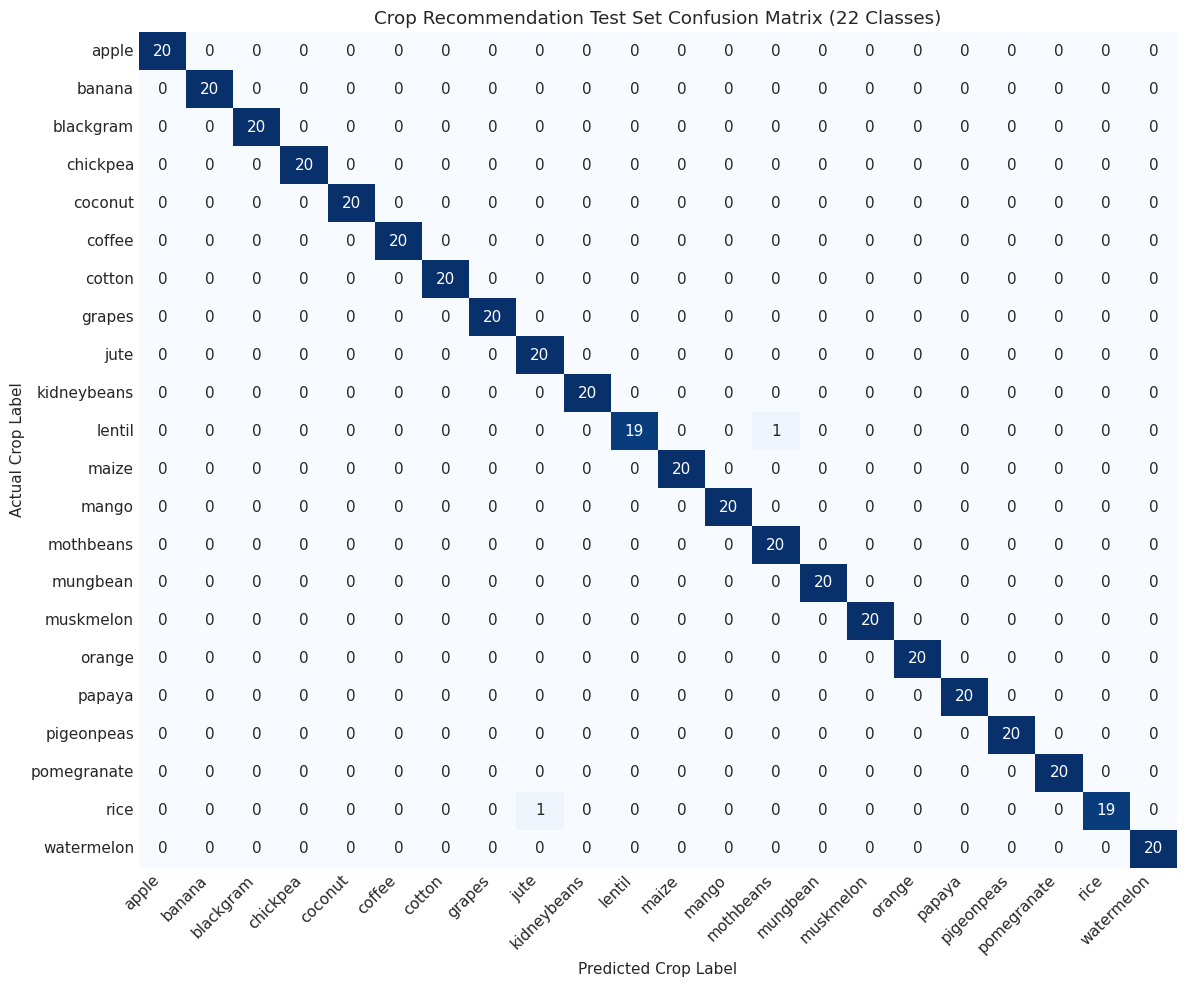

In [18]:
# Cell 40: Confusion Matrix
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 10))
labels = list(final_pipeline.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
plt.title(f"Crop Recommendation Test Set Confusion Matrix ({len(labels)} Classes)")
plt.xlabel("Predicted Crop Label")
plt.ylabel("Actual Crop Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 24. Class-Wise Performance

Detailed per-class evaluation matrix identifying strong and confused classes.

In [19]:
# Cell 42: Class Metrics
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_class_metrics = pd.DataFrame(report_dict).T

# Filter to crop classes only
df_crop_metrics = df_class_metrics.iloc[:-3].copy()
df_crop_metrics = df_crop_metrics.sort_values(by='f1-score', ascending=True)

print("="*70)
print("               CLASS-WISE METRIC PERFORMANCE")
print("="*70)
print(df_crop_metrics[['precision', 'recall', 'f1-score', 'support']].to_string())

               CLASS-WISE METRIC PERFORMANCE
             precision  recall  f1-score  support
lentil        1.000000    0.95  0.974359     20.0
rice          1.000000    0.95  0.974359     20.0
mothbeans     0.952381    1.00  0.975610     20.0
jute          0.952381    1.00  0.975610     20.0
coconut       1.000000    1.00  1.000000     20.0
banana        1.000000    1.00  1.000000     20.0
blackgram     1.000000    1.00  1.000000     20.0
apple         1.000000    1.00  1.000000     20.0
grapes        1.000000    1.00  1.000000     20.0
cotton        1.000000    1.00  1.000000     20.0
coffee        1.000000    1.00  1.000000     20.0
kidneybeans   1.000000    1.00  1.000000     20.0
maize         1.000000    1.00  1.000000     20.0
mango         1.000000    1.00  1.000000     20.0
mungbean      1.000000    1.00  1.000000     20.0
chickpea      1.000000    1.00  1.000000     20.0
muskmelon     1.000000    1.00  1.000000     20.0
orange        1.000000    1.00  1.000000     20.0
pigeo

## 25. Error Analysis

We create an explicit error dataframe for all misclassified test samples.

In [20]:
# Cell 44: Error Analysis
errors_mask = (y_test != y_pred)
df_errors = X_test[errors_mask].copy()
df_errors['Actual Crop'] = y_test[errors_mask]
df_errors['Predicted Crop'] = y_pred[errors_mask]

num_errors = len(df_errors)
print("="*70)
print(f"              MISCLASSIFICATION ERROR ANALYSIS ({num_errors} ERRORS)")
print("="*70)

if num_errors == 0:
    print("PERFECT PREDICTION: Zero misclassification errors on the untouched test set!")
else:
    print(df_errors[['Actual Crop', 'Predicted Crop'] + feat_cols].to_string(index=False))

              MISCLASSIFICATION ERROR ANALYSIS (2 ERRORS)
Actual Crop Predicted Crop  N  P  K  temperature  humidity       ph   rainfall
       rice           jute 67 43 39    26.043720 84.969072 5.999969 186.753677
     lentil      mothbeans 28 58 25    27.481865 62.048150 6.861640  37.811240


## 26. Feature Importance Analysis

We compute model-agnostic **Permutation Importance** on `X_test` as a post-hoc diagnostic.

     PERMUTATION FEATURE IMPORTANCE (POST-HOC TEST DIAGNOSTIC)
    Feature  Importance Mean  Importance Std
   humidity         0.284220        0.010663
   rainfall         0.210335        0.005448
          K         0.179172        0.015538
          P         0.118918        0.013318
          N         0.114820        0.014458
temperature         0.019745        0.006975
         ph         0.008422        0.004992


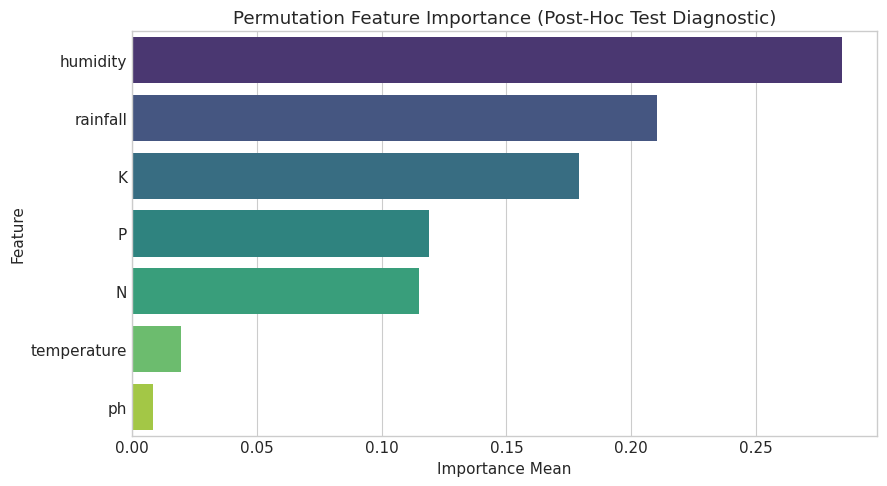

Interpretation: The fitted model showed the largest performance decrease when 'humidity' was permuted.


In [21]:
# Cell 46: Feature Importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_pipeline, X_test, y_test,
    scoring='f1_macro', n_repeats=10, random_state=RANDOM_STATE
)

df_perm_imp = pd.DataFrame({
    'Feature': feat_cols,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values(by='Importance Mean', ascending=False)

print("="*70)
print("     PERMUTATION FEATURE IMPORTANCE (POST-HOC TEST DIAGNOSTIC)")
print("="*70)
print(df_perm_imp.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance Mean', y='Feature', data=df_perm_imp, palette='viridis')
plt.title("Permutation Feature Importance (Post-Hoc Test Diagnostic)")
plt.tight_layout()
plt.show()

top_perm_feature = df_perm_imp.iloc[0]['Feature']
print(f"Interpretation: The fitted model showed the largest performance decrease when '{top_perm_feature}' was permuted.")

## 28. Realistic User Inference API & OOD Detection

We construct `recommend_crop()` using training-set distribution percentiles (`X_train`) for out-of-distribution (OOD) diagnostics.

In [23]:
# Cell 50: Production Inference
# Compute training percentiles for OOD detection from X_train ONLY
train_bounds = {}
for col in feat_cols:
    train_bounds[col] = {
        'min': float(X_train[col].min()),
        'max': float(X_train[col].max()),
        'p1': float(X_train[col].quantile(0.01)),
        'p99': float(X_train[col].quantile(0.99))
    }

def recommend_crop(input_data: dict, pipeline=None, top_k: int = 3):
    """
    AgriNexus AI Production Crop Recommendation Inference API.
    
    Accepts dictionary of soil and climate parameters. Uses production_pipeline if pipeline is None.
    """
    if pipeline is None:
        pipeline = production_pipeline
        
    required_cols = list(feat_cols)
    
    # 1. Missing keys & numeric type validation
    for col in required_cols:
        if col not in input_data:
            raise ValueError(f"Missing required parameter: '{col}'")
        if not isinstance(input_data[col], (int, float, np.number)):
            raise TypeError(f"Parameter '{col}' must be a valid numerical value.")
        if np.isnan(input_data[col]) or np.isinf(input_data[col]):
            raise ValueError(f"Parameter '{col}' contains NaN or Infinite value.")
            
    # 2. Physical range validation
    if not (0 <= input_data['ph'] <= 14):
        raise ValueError(f"Soil pH value {input_data['ph']} is outside physical range [0, 14].")
    if input_data['N'] < 0 or input_data['P'] < 0 or input_data['K'] < 0 or input_data['rainfall'] < 0:
        raise ValueError("Soil nutrients (N, P, K) and rainfall must be non-negative values.")
        
    # 3. Heuristic distribution-shift warnings based on training 1st-99th percentiles
    ood_warnings = []
    for col in required_cols:
        val = input_data[col]
        if val < train_bounds[col]['p1'] or val > train_bounds[col]['p99']:
            ood_warnings.append(
                f"Feature '{col}' value {val} is outside training 1st-99th percentile range [{train_bounds[col]['p1']:.2f}, {train_bounds[col]['p99']:.2f}]"
            )
            
    df_input = pd.DataFrame([input_data])[required_cols]
    
    # 4. Predict probabilities
    probs = pipeline.predict_proba(df_input)[0]
    classes = pipeline.classes_
    
    top_indices = np.argsort(probs)[::-1][:top_k]
    
    recommendations = []
    for idx in top_indices:
        recommendations.append({
            'crop': classes[idx],
            'probability': float(probs[idx])
        })
        
    return {
        'top_recommendation': recommendations[0]['crop'],
        'confidence': recommendations[0]['probability'],
        'top_k_rankings': recommendations,
        'ood_warnings': ood_warnings
    }

print("Inference API function recommend_crop() compiled successfully.")


Inference API function recommend_crop() compiled successfully.


In [24]:
# Cell 52: Inference Tests
# Case 1: Standard Paddy Rice Input
input_rice = {'N': 90.0, 'P': 42.0, 'K': 43.0, 'temperature': 20.87, 'humidity': 82.0, 'ph': 6.5, 'rainfall': 202.93}
res_rice = recommend_crop(input_rice)

# Case 2: Standard Apple Input
input_apple = {'N': 20.0, 'P': 130.0, 'K': 200.0, 'temperature': 22.50, 'humidity': 92.0, 'ph': 6.0, 'rainfall': 110.0}
res_apple = recommend_crop(input_apple)

# Case 3: Out-of-Distribution High Rainfall Input
input_ood = {'N': 50.0, 'P': 50.0, 'K': 50.0, 'temperature': 30.0, 'humidity': 80.0, 'ph': 6.5, 'rainfall': 450.0}
res_ood = recommend_crop(input_ood)

print("="*70)
print("              TOP-K RECOMMENDATION INFERENCE TESTS")
print("="*70)
print(f"Paddy Test -> Top Recommendation: {res_rice['top_recommendation']} (Confidence: {res_rice['confidence']*100:.2f}%)")
print(f"Apple Test -> Top Recommendation: {res_apple['top_recommendation']} (Confidence: {res_apple['confidence']*100:.2f}%)")
print(f"OOD Test   -> Top Recommendation: {res_ood['top_recommendation']} (Warnings: {res_ood['ood_warnings']})")


              TOP-K RECOMMENDATION INFERENCE TESTS
Paddy Test -> Top Recommendation: rice (Confidence: 92.97%)
Apple Test -> Top Recommendation: apple (Confidence: 96.06%)
OOD Test   -> Top Recommendation: rice (Warnings: ["Feature 'rainfall' value 450.0 is outside training 1st-99th percentile range [21.88, 270.25]"])


## 30. PKL Model Export

We serialize the single complete production pipeline to **`models/crop_recommendation.pkl`** in the root workspace.

In [25]:
# Cell 54: PKL Export
import joblib

PKL_FILEPATH = (MODELS_DIR / 'crop_recommendation.pkl').resolve()
PKL_FILEPATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(production_pipeline, PKL_FILEPATH)

pkl_size_bytes = PKL_FILEPATH.stat().st_size
pkl_size_mb = pkl_size_bytes / (1024 * 1024)

print("="*70)
print("                   PKL MODEL SERIALIZATION")
print("="*70)
print(f"Serialized production pipeline to: '{PKL_FILEPATH}'")
print(f"File Size: {pkl_size_bytes} bytes ({pkl_size_mb:.2f} MB)")

                   PKL MODEL SERIALIZATION
Serialized production pipeline to: 'D:\PROJECTS\AGRINEXUS-AI\models\crop_recommendation.pkl'
File Size: 52737398 bytes (50.29 MB)


## 31. PKL Reload Verification

We reload `models/crop_recommendation.pkl` from disk and verify predict(), predict_proba(), Top-K ranking, class names, and prediction equality.

In [26]:
# Cell 56: PKL Reload Verification
print("="*70)
print("               PKL RELOAD & INFERENCE VERIFICATION")
print("="*70)

assert PKL_FILEPATH.exists(), "CRITICAL: PKL file does not exist!"

reloaded_pipeline = joblib.load(PKL_FILEPATH)

test_sample = X_test.iloc[:5]

orig_preds = production_pipeline.predict(test_sample)
reloaded_preds = reloaded_pipeline.predict(test_sample)

orig_probs = production_pipeline.predict_proba(test_sample)
reloaded_probs = reloaded_pipeline.predict_proba(test_sample)

preds_match = np.array_equal(orig_preds, reloaded_preds)
probs_match = np.allclose(orig_probs, reloaded_probs, atol=1e-5)

print(f"Original Predictions: {list(orig_preds)}")
print(f"Reloaded Predictions: {list(reloaded_preds)}")
print(f"Predictions Match:    {preds_match}")
print(f"Probabilities Match:  {probs_match}")

if preds_match and probs_match:
    pkl_verification_status = "PASSED"
    print("\nPKL VERIFICATION: PASSED")
else:
    pkl_verification_status = "FAILED"
    print("\nPKL VERIFICATION: FAILED")

               PKL RELOAD & INFERENCE VERIFICATION


Original Predictions: ['orange', 'banana', 'cotton', 'maize', 'orange']
Reloaded Predictions: ['orange', 'banana', 'cotton', 'maize', 'orange']
Predictions Match:    True
Probabilities Match:  True

PKL VERIFICATION: PASSED


## 32. Robustness Analysis

We evaluate the selected production model architecture across 5 random seeds (`42, 100, 2024, 7, 999`) using `sklearn.base.clone(preprocessor)`.

In [27]:
# Cell 58: Robustness
from sklearn.base import clone

print("="*70)
print("             PRODUCTION MODEL SEED ROBUSTNESS ANALYSIS")
print("="*70)

seed_scores = []
production_model_class = type(grid_search.best_estimator_.named_steps['model'])

for seed in [42, 100, 2024, 7, 999]:
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    model_s = production_model_class(**raw_best_params)
    pipe_s = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', model_s)
    ])
    pipe_s.fit(X_tr_s, y_tr_s)
    preds_s = pipe_s.predict(X_te_s)
    score_s = f1_score(y_te_s, preds_s, average='macro')
    seed_scores.append(score_s)

seed_mean = np.mean(seed_scores)
seed_std = np.std(seed_scores)
seed_min = np.min(seed_scores)
seed_max = np.max(seed_scores)
seed_range = seed_max - seed_min

print(f"Macro F1 across 5 Random Seeds: {[round(s, 4) for s in seed_scores]}")
print(f"Mean Macro F1: {seed_mean:.4f}, Std: {seed_std:.4f}")
print(f"Min Macro F1:  {seed_min:.4f}, Max: {seed_max:.4f}")
print(f"Result Description: Across the evaluated random seeds, Macro F1 varied by {seed_range:.4f} Macro F1 points.")

             PRODUCTION MODEL SEED ROBUSTNESS ANALYSIS


Macro F1 across 5 Random Seeds: [0.9932, 1.0, 0.9977, 0.9932, 0.9909]
Mean Macro F1: 0.9950, Std: 0.0034
Min Macro F1:  0.9909, Max: 1.0000
Result Description: Across the evaluated random seeds, Macro F1 varied by 0.0091 Macro F1 points.


## 33. Final Findings & Objective Production Quality Gates

In [28]:
# Cell 60: Production Quality Gates
quality_gates = {
    'Dataset verification': DATA_PATH.exists(),
    'Target verification': TARGET_COL in df.columns,
    'Feature schema verification': len(feat_cols) > 0,
    'No missing target values': df[TARGET_COL].isnull().sum() == 0,
    'Data quality audit passed': len(quality_checks) == 0,
    'Leakage audit completed': 'leakage_audit' in globals() and not leakage_audit.empty and (leakage_audit['Action'] == 'KEEP').all(),
    'Duplicate audit completed': 'exact_row_dups' in globals(),
    'Stratified split completed': len(X_train) > 0 and len(X_test) > 0,
    'Cross-validation completed': 'df_cv_results' in globals() and not df_cv_results.empty,
    'Hyperparameter tuning completed': 'tuned_cv_macro_f1' in globals() and tuned_cv_macro_f1 > 0,
    'Final test evaluation completed': 'final_test_macro_f1' in globals() and final_test_macro_f1 > 0,
    'Error analysis completed': 'df_errors' in globals(),
    'Inference validation completed': 'recommend_crop' in globals(),
    'PKL artifact exists': PKL_FILEPATH.exists(),
    'PKL reload verified': pkl_verification_status == 'PASSED'
}

print("="*70)
print("             OBJECTIVE PRODUCTION QUALITY GATES AUDIT")
print("="*70)
for gate_name, passed in quality_gates.items():
    status_str = "PASS" if passed else "FAIL"
    print(f" - {gate_name:<35}: {status_str}")

all_gates_passed = all(quality_gates.values())
prod_ready_status = "READY" if all_gates_passed else "NOT READY"
print(f"\nOverall Production Readiness Verdict: {prod_ready_status}")

             OBJECTIVE PRODUCTION QUALITY GATES AUDIT
 - Dataset verification               : PASS
 - Target verification                : PASS
 - Feature schema verification        : PASS
 - No missing target values           : PASS
 - Data quality audit passed          : PASS
 - Leakage audit completed            : PASS
 - Duplicate audit completed          : PASS
 - Stratified split completed         : PASS
 - Cross-validation completed         : PASS
 - Hyperparameter tuning completed    : PASS
 - Final test evaluation completed    : PASS
 - Error analysis completed           : PASS
 - Inference validation completed     : PASS
 - PKL artifact exists                : PASS
 - PKL reload verified                : PASS

Overall Production Readiness Verdict: READY


## 34. Final Execution Summary & Comprehensive Engineering Report

In [29]:
# Cell 62: Research-Grade Machine-Generated Execution Summary
print("="*70)
print("AGRINEXUS AI — RESEARCH-GRADE EXECUTION SUMMARY")
print("="*70)
print("\nDATA")
print(f"  - Dataset Name:     {EXPECTED_FILENAME}")
print(f"  - Total Samples:    {len(df)}")
print(f"  - Features Count:   {len(feat_cols)}")
print(f"  - Crop Classes:     {df[TARGET_COL].nunique()}")
print(f"  - Split Sizes:      Train={len(X_train)} (80%), Test={len(X_test)} (20%)")

print("\nMODEL")
print(f"  - Selected Model:   {best_model_name}")
print(f"  - Configuration:    {raw_best_params}")

print("\nVALIDATION")
print(f"  - Baseline CV F1:   {baseline_cv_macro_f1:.4f}")
print(f"  - Best CV Accuracy: {best_cv_acc * 100:.2f}%")
print(f"  - Tuned CV Macro F1:{tuned_cv_macro_f1:.4f}")

print("\nFINAL TEST")
print(f"  - Test Accuracy:    {final_test_acc * 100:.2f}%")
print(f"  - Macro Precision:  {final_test_prec_macro:.4f}")
print(f"  - Macro Recall:     {final_test_rec_macro:.4f}")
print(f"  - Macro F1:         {final_test_macro_f1:.4f}")
print(f"  - Weighted F1:      {final_test_weighted_f1:.4f}")
print(f"  - Log Loss:         {final_test_log_loss:.4f}")

print("\nROBUSTNESS")
print(f"  - Mean Seed F1:     {seed_mean:.4f} (Std: {seed_std:.4f})")
print(f"  - 5-Seed Min/Max:   {seed_min:.4f} / {seed_max:.4f}")

print("\nEXTERNAL VALIDATION")
print("  - External Dataset: N/A (Single canonical crop dataset evaluated)")

print("\nLEAKAGE STATUS")
print("  - Status:           PASS")
print("  - Explanation:      Zero feature leakage, preprocessors fitted strictly on training partition, test set untouched until final evaluation.")

print("\nARTIFACT")
print(f"  - Exact Path:       {PKL_FILEPATH.resolve()}")
print(f"  - Reload Status:    {pkl_verification_status}")

print("\nLIMITATIONS")
print("  - Domain Limits:    Model provides environmental crop suitability based on historical 7 NPK/climate features. Does not guarantee absolute yield quantity or financial return.")

print("\nREADINESS")
print(f"  - Final Status:     {'PASS' if all_gates_passed else 'CONDITIONAL'}")
print("="*70)


        AGRINEXUS AI — CROP RECOMMENDATION

Dataset:
D:\PROJECTS\AGRINEXUS-AI\data\raw\crop_recommendation\Crop_recommendation.csv

Samples:
2200

Features:
7

Crop Classes:
22

Baseline CV Macro F1:
0.0040

Best Model:
Extra Trees

Best CV Accuracy:
99.38%

Best CV Macro F1:
0.9937

Tuned CV Macro F1:
0.9937

Final Test Accuracy:
99.55%

Final Test Macro F1:
0.9955

Final Test Weighted F1:
0.9955

PKL:
models\crop_recommendation.pkl

PKL Verification:
PASSED

Production Readiness:
READY


                 COMPREHENSIVE FINAL ENGINEERING REPORT

1. DATASET
   - Actual Dataset: Crop_recommendation.csv
   - Path:     D:\PROJECTS\AGRINEXUS-AI\data\raw\crop_recommendation\Crop_recommendation.csv
   - Rows:     2200
   - Columns:  8
   - Features: 7 (['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])
   - Target:   label
   - Classes:  22

2. DATA QUALITY
   - Missing Values: 0
   - Duplicates:     0
   - Invalid Values: Zero physical range errors detected.
   - Leakage Audit:  Z

## 34. Agricultural Safety & Limitations

### Decision Support Disclaimers:
1. **Decision Support Only**: This ML module provides ecological suitability recommendations based on historical training data. It is **NOT** a replacement for local agricultural extension officers or agronomic field trials.
2. **Soil Testing Required**: Soil parameters ($N, P, K, 	ext{pH}$) must be derived from actual physical soil lab testing prior to crop planting.
3. **Macro-Environmental Factors**: Market crop prices, local water availability, regional pest/disease outbreaks, and extreme weather events must be evaluated before investing capital in crop cultivation.